In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import simpson
from scipy.interpolate import interp1d

dust from the planet’s molten surface condenses within a thermally driven wind and is carried by a gaseous outow to a
region where the gas density is sufficiently low for the dust to decouple from the
gas dynamically. At this stage, the dust’s path is determined by the stellar ra-
diation pressure and the stellar gravity, forming it into a cometary-like tail that
trails (or leads) the planet. As the gas
density decreases further from the planet, the sublimation temperature decreases. This causes the dust to gradually sublimate as it travels
along the tail, leading to a reduction in the optical depth with increasing distance from the planet.


dust grains leave the planetary atmosphere at the thermal
velocity of gas particles and are distributed either from the entire planetary surface
(spherical outow geometry) or just the day-side (day-side outow geometry).

In [2]:
# DEFINE INTERNAL UNITS

G_cgs = 6.67259 * 10**-8    # G in cgs
c_cgs = 2.99 * 10**10       # cm/s
M_sun = 1.9891 * 10**33     # solar mass in g
R_sun = 6.9598 * 10**10     # solar radius in cm 
L_sun = 3.828e33            # sun luminosity in erg/s
M_earth = 5.976 * 10**27    # earth mass in g
R_earth = 6.378 * 10**8     # earth radius in cm
ly = 9.463 * 10**17         # light year in cm
parsec = 3.086 * 10**18     # parsec in cm
AU = 1.496 * 10**13         # astronomical unit in cm

def v_IU(M_cgs, r_cgs, v_cgs):
    return np.sqrt(r_cgs/(G_cgs*M_cgs))*v_cgs

def t_IU(M_cgs, r_cgs, t_cgs):
    return t_cgs/(np.sqrt(r_cgs/(G_cgs*M_cgs))*r_cgs)

#def L_IU(M_cgs, r_cgs, L_cgs):
#    t0 = np.sqrt(r_cgs**3 / (G_cgs * M_cgs))
#    L0 = M_cgs * r_cgs**2 / t0**3
#    return L_cgs / L0

# 1 Msun and 1 AU as mass and distance units
print("1 km/s expressed in internal units is: %f" % (v_IU(M_sun,AU,1*10**5)))
print("26.22 km/s expressed in internal units is: %f" % (v_IU(M_sun,AU,26.22*10**5)))
print("1 year expressed in internal units is: %f" % (t_IU(M_sun,AU,3.156*10**7)))

# BD+05 4868 Ab period, and semimajor axis
print("1.27 days expressed in internal units is: %f" % (t_IU(M_sun,AU,1.27*3600*24)))

#print("L_sun expressed in internal units is: %e " % (L_IU(M_sun, AU, L_sun)))

1 km/s expressed in internal units is: 0.033573
26.22 km/s expressed in internal units is: 0.880284
1 year expressed in internal units is: 6.283696
1.27 days expressed in internal units is: 0.021847


In [3]:
# Semimajor axis and vircular velocity (in internal units)
period = 0.021847
M_star = 0.70 # solar masses
a = (M_star * period**2 / (4*np.pi**2))**(1/3)

print(f"BD+05 4868 Ab semimajor axis is: {a} AU")

# circular velocity
v_circ = np.sqrt(M_star/a)

print(f"BD+05 4868 Ab circular velocity is: {v_circ} = {v_circ/0.033573} km/s")

M_planet = 0.03 * M_earth/M_sun

R_Hill = a * (M_planet/(3*M_star))**(1/3)
print(f"BD+05 4868 Ab Hill radius is: {R_Hill} AU")



BD+05 4868 Ab semimajor axis is: 0.020378582576332595 AU
BD+05 4868 Ab circular velocity is: 5.86086925549315 = 174.57091280174993 km/s
BD+05 4868 Ab Hill radius is: 7.134977655066538e-05 AU


In [4]:
def g(r):
    """
    Gravitational field around the star
    Gets in input the position (numpy array).
    Returns the force array (numpy array).
    """
    r = np.asarray(r, dtype=float)
    
    return - M_star * r / np.linalg.norm(r)**3



def g_dust(r,r_planet,beta):  

    # Stellar gravity + radiation pressure
    a_star = -(1 - beta) * M_star * r / np.linalg.norm(r)**3

    # Planet gravity
    dr = r - r_planet
    d = np.linalg.norm(dr)

    a_planet = -M_planet * dr / d**3

    return a_star + a_planet


def rk4_integrator(g, r, v, dt, *args):

    k1_r = v
    k1_v = g(r, *args)

    k2_r = v + 0.5 * dt * k1_v
    k2_v = g(r + 0.5 * dt * k1_r, *args)

    k3_r = v + 0.5 * dt * k2_v
    k3_v = g(r + 0.5 * dt * k2_r, *args)

    k4_r = v + dt * k3_v
    k4_v = g(r + dt * k3_r, *args)

    r_new = r + dt/6 * (k1_r + 2*k2_r + 2*k3_r + k4_r)
    v_new = v + dt/6 * (k1_v + 2*k2_v + 2*k3_v + k4_v)

    return r_new, v_new
    

**Radiation pressure**

$\beta$ is the ratio of the radiation-pressure force to stellar gravity.

$\boldsymbol{a_\star} = -(1-\beta)\frac{GM_\star}{r^3}\boldsymbol{r}$


Assuming dust grains are spherical:

$$\beta=\frac{1}{4\pi cG}\frac{L_\star}{M_\star}e^{-\tau_\star}\kappa(T_\star,s)$$

where $L_\star$ is stellar luminosity, $\tau_\star$ is the optical depth of the dust cloud to stellar
irradiation at the grain’s position, and $\kappa$ is the radiation-pressure Planck-mean
opacity (weighted by the spectrum of the incoming stellar radiation) at the stellar temperature $T_\star$ , for a particle of radius $s$.

$$\kappa(T_\star, s)=\frac{
\displaystyle \int_0^\infty \kappa_\lambda(s)\, B_\lambda(T_\star)\, d\lambda}{\displaystyle \int_0^\infty B_\lambda(T_\star)\, d\lambda}$$

The stellar radiation gets geometrically diluted as it travels to the dust, but its spectral shape remains characterized by $T_\star$ (ignoring wavelength-dependent absorption between star and grain).



The dust temperature $T_d$ is a separate quantity. That is what matters for things like sublimation and thermal emission, whereas $T_\star$, that determines the wavelength distribution of the photons pushing on the grain.

 **Sublimation**

Fe2SiO4__DHS: ['Fe2SiO4[s]'], 1 compositions, 100 radii, 5996 wavelengths, grid R=1000. DHS. T = ?. Averaged Ex, EY, Ez? Refractive index of Fe2SiO4[s]; Fabian et al. (2001), A&A Vol. 378; Database of Optical Constants for Cosmic Dust, Laboratory Astrophysics Group of the AIU Jena
Mg2SiO4__DHS: ['Mg2SiO4_1809K_B1U', 'Mg2SiO4_1818K_B2U', 'Mg2SiO4_1948K_B3U'], 1 compositions, 300 radii, 5996 wavelengths, grid R=1000. T = 1800 K, Mixed 1/3 x, 1/3 y, 1/3 z with Linear EMT, opacity coefficients computed with DHS theory


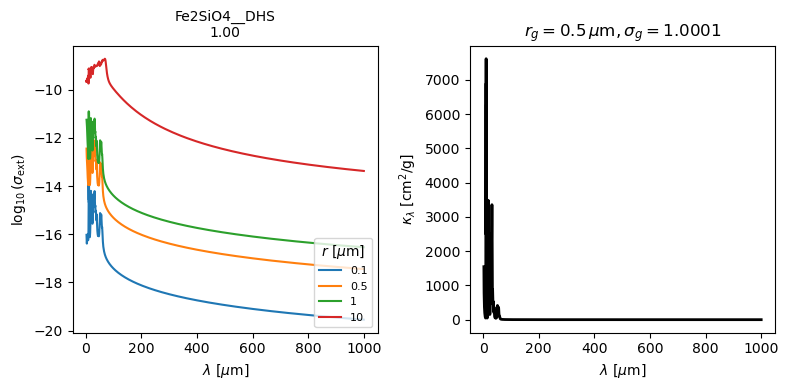

In [15]:
# load opacities from slabby

import sys
from pathlib import Path

sys.path.insert(0, str(Path("slabby_copy/").resolve()))

from retrievals import load_opacities

species_list = [
    "Fe2SiO4__DHS",
    "Mg2SiO4__DHS",
]

op_fun = load_opacities(
    dust_species=species_list,
    spectral_range=(2.5,1000)
)

op_fun['Fe2SiO4__DHS'](
    r_g = 0.5,
    sigma_g = 1.0001,
    plot=True,
    plot_cross_sections=True,
    plot_radii = [0.1,0.5,1,10],
);


/tmp/ipykernel_189984/578993196.py:19: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,1e2)


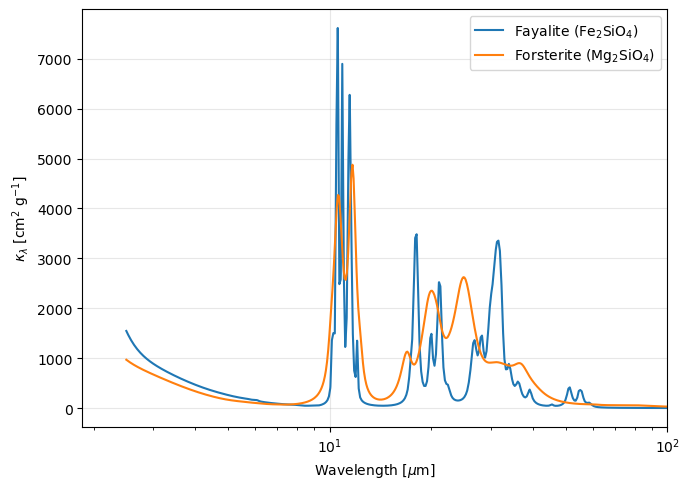

In [19]:
wl,op_fayalite = op_fun['Fe2SiO4__DHS'](
    r_g = 0.5,
    sigma_g = 1.0001,
);
wl,op_forsterite = op_fun['Mg2SiO4__DHS'](
    r_g = 0.5,
    sigma_g = 1.0001,
);

plt.figure(figsize=(7, 5))

plt.plot(wl, op_fayalite, label='Fayalite (Fe$_2$SiO$_4$)')
plt.plot(wl, op_forsterite, label='Forsterite (Mg$_2$SiO$_4$)')

plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel(r'$\kappa_\lambda$ [cm$^2$ g$^{-1}$]')

plt.xscale('log')
plt.xlim(0,1e2)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:

T_star = 4540                  # in K  Hon et al 2025
L_star = 0.192 * L_sun         # cgs Hon et al 2025
M_star_cgs = 0.70 * M_sun

# CGS constants
h_cgs = 6.62607015e-27      # erg s
c_cgs = 2.99792458e10       # cm / s
kB_cgs = 1.380649e-16       # erg / K


def B_lambda(wl_cm, T):
    """
    Planck function B_lambda in CGS:
    erg s^-1 cm^-2 sr^-1 cm^-1

    wl_cm : wavelength in cm
    T     : temperature in K
    """
    x = h_cgs * c_cgs / (wl_cm * kB_cgs * T)

    return (
        2 * h_cgs * c_cgs**2 / wl_cm**5
        / np.expm1(x)
    )


def planck_mean_opacity(opacity, T, s, wl_min=0.01, wl_max=1000, n_wl=10000):
    """
    Planck-mean opacity:

        kappa(T,s) = integral kappa_lambda(s) B_lambda(T) dlambda
                     ---------------------------------------------
                           integral B_lambda(T) dlambda

    opacity must return opacity as a function of wl, in cm^2/, for a FIXED SIZE

    wl_min, wl_max are in micron.
    """

    # logarithmic wavelength grid in micron
    wl_um = np.geomspace(wl_min, wl_max, n_wl)

    # convert wavelength to cm for Planck function/integration
    wl_cm = wl_um * 1e-4

    # opacity in cm^2/g
    kappa_lambda = opacity(wl_um)

    B = B_lambda(wl_cm, T)

    numerator = simpson(kappa_lambda * B, x=wl_cm)
    denominator = simpson(B, x=wl_cm)

    return numerator / denominator


def compute_beta(L_star,M_star_cgs,T_star,tau,size,kappa):

    kappa_planck = planck_mean_opacity(kappa, T_star, size, wl_min=0.01, wl_max=1000, n_wl=10000)

    return (
        kappa_planck * L_star
        / (4 * np.pi * G_cgs * c_cgs * M_star_cgs)
        * np.exp(-tau)
    )



In [8]:

    
grain = {
    "size": 0.03, # micron
    "species": 'Fe2SiO4__DHS', 
}
    
# beta depends on the optical depth and on k
species = grain["species"]
wl,opacity = op_fun[species](
    r_g = grain["size"],
    sigma_g = 1,
    ) 

# κ(λ), with κ = 0 outside the opacity wavelength range
kappa = interp1d(wl,opacity,kind="linear",bounds_error=False,fill_value=0.0,)

tau = 0
beta = compute_beta(
    L_star=L_star,
    M_star_cgs=M_star_cgs,
    T_star=T_star,
    tau=0,
    size=grain['size'],
    kappa=kappa
)

print(beta)




0.004743265978008874


In [20]:
# Precompute beta(size) for each species

size_grid = np.geomspace(0.01, 100, 300)  # micron

beta_of_size = {}

for species in species_list:

    beta_grid = np.zeros_like(size_grid)

    for i, size in enumerate(size_grid):

        wl, opacity = op_fun[species](
            r_g=size,
            sigma_g=1,
        )

        kappa = interp1d(
            wl,
            opacity,
            bounds_error=False,
            fill_value=0.0,
        )

        beta_grid[i] = compute_beta(
            L_star=L_star,
            M_star_cgs=M_star_cgs,
            T_star=T_star,
            tau=0,
            size=size,
            kappa=kappa,
        )

    beta_of_size[species] = interp1d(
        np.log(size_grid),
        beta_grid,
        bounds_error=False,
        fill_value="extrapolate",
    )

In [ ]:
print(beta)

# Run simulation

In [23]:
# Set planet initial conditions

# PLANET
r_0 = np.array([a,0,0])
v_0 = np.array([0,v_circ,0])
a_0 = g(r_0)

# dust properties (for all species)
r_g = 1
sigma_g = 1.5


In [24]:
r_planet = [r_0]
v_planet = [v_0]
a_planet = [a_0]

live_grains = []

dt = period * 1e-2

# time array
times = np.arange(0, 1*period, dt)

for t in tqdm(times, desc="Integrating orbit"):

    # Planet motion
    r_new, v_new = rk4_integrator(g,r_planet[-1], v_planet[-1], dt,)
    r_planet.append(r_new)
    v_planet.append(v_new)


    # Evolve already existing grains
    for grain in live_grains:

        species = grain["species"]
        
        beta0 = beta_of_size[species](np.log(grain["size"]))

        # compute tau
        tau = 0
        
        beta = beta0 * np.exp(-tau)

        grain["r"], grain["v"] = rk4_integrator(
            g_dust,
            grain["r"],
            grain["v"],
            dt,
            r_new,
            beta,
        )

    # At each time step inject 100 dust grains, initially at R_Hill.
    # Their size follow a lognormal distribution centered on r_g and with sigma_g std 
    # real number of dust grains must be multiplied by ...
    n_dust = 100
    
    for i in range(n_dust):

        # Random position on star-facing Hill hemisphere
        while True:
            direction = np.random.normal(size=3)
            direction /= np.linalg.norm(direction)
    
            if np.dot(direction, r_new) < 0:
                break
    
        r_dust = r_new + R_Hill * direction
    
        # Random velocity direction facing the star
        while True:
            v_direction = np.random.normal(size=3)
            v_direction /= np.linalg.norm(v_direction)
    
            if np.dot(v_direction, r_new) < 0:
                break

        
        v_eject = 0.01             # MUST BE EXPRESSED IN INTERNAL UNITS
        v_dust = v_new + v_eject * v_direction

        
        # Grain size from lognormal distribution
        size = np.random.lognormal(
            mean=np.log(r_g),
            sigma=np.log(sigma_g),
        )
    
        grain = {
            "r": r_dust,
            "v": v_dust,
            "size": size,
            "species": 'Fe2SiO4__DHS',
        }
    
        live_grains.append(grain)

r_planet = np.array(r_planet)



Integrating orbit: 100%|██████████████████████| 100/100 [00:41<00:00,  2.39it/s]


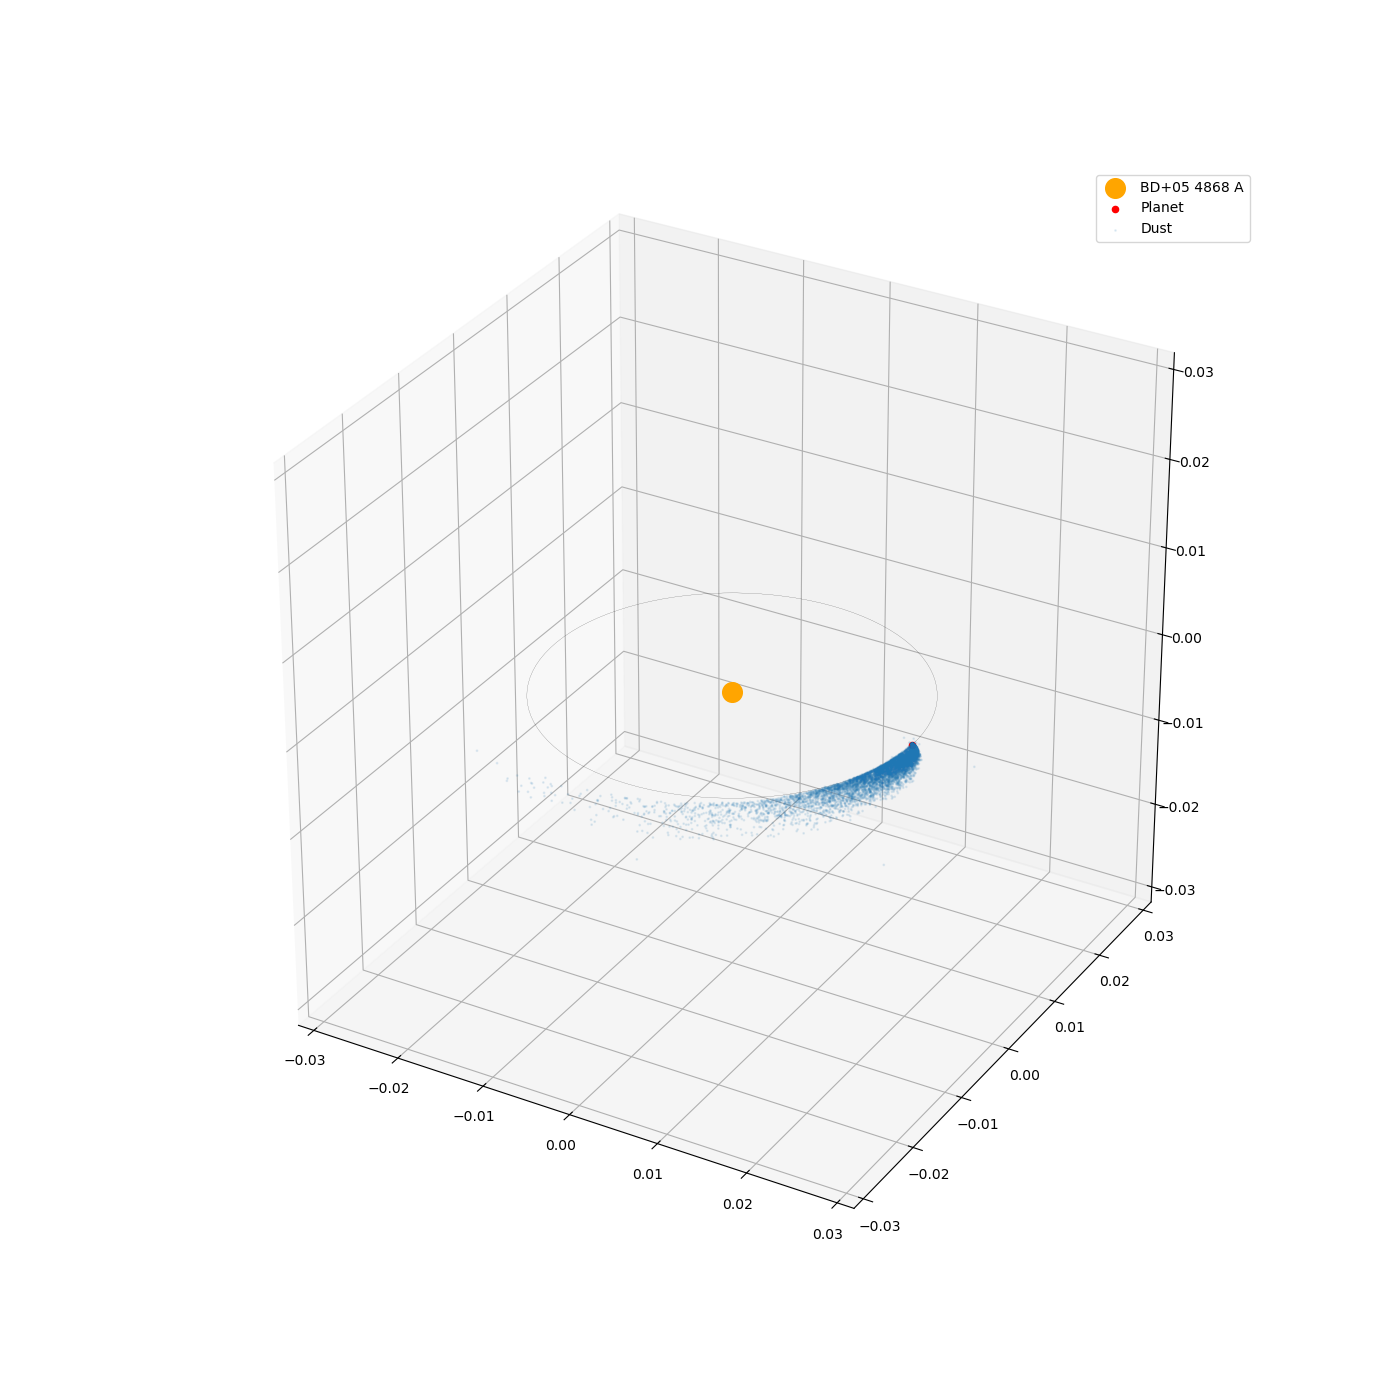

In [25]:
%matplotlib widget


fig = plt.figure(figsize=(14,14))
ax = fig.add_subplot(111, projection="3d")
ax.set_aspect("equal")

# Planet orbit
ax.plot(
    r_planet[:,0],
    r_planet[:,1],
    r_planet[:,2],
    lw=0.1,
    color='black',
)

# Star
ax.scatter(
    0, 0, 0,
    color="orange",
    s=200,
    label="BD+05 4868 A"
)

# Planet final position
ax.scatter(
    r_planet[-1,0],
    r_planet[-1,1],
    r_planet[-1,2],
    color="red",
    s=20,
    label="Planet",
    zorder=5
)

# Dust final positions
r_dust_final = np.array([grain["r"] for grain in live_grains])

ax.scatter(
    r_dust_final[:,0],
    r_dust_final[:,1],
    r_dust_final[:,2],
    s=1,
    alpha=0.1,
    label="Dust"
)

#ax.set_xlabel("x")
#ax.set_ylabel("y")
#ax.set_zlabel("z")
#ax.set_title("Planet + Dust")

ax.set_xlim(-1.5*a, 1.5*a)
ax.set_ylim(-1.5*a, 1.5*a)
ax.set_zlim(-1.5*a, 1.5*a)

ax.legend()

plt.show()